In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.io import imread, imsave
from skimage.color import gray2rgb, rgb2gray
from skimage.filters import threshold_otsu, gaussian  # added gaussian smoothing
from skimage.morphology import remove_small_objects, binary_closing
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes  # corrected import for hole filling

try:
    import pydensecrf.densecrf as dcrf
    from pydensecrf.utils import unary_from_labels, create_pairwise_bilateral

    HAVE_CRf = True
except Exception:
    HAVE_CRf = False




In [2]:
def rle_decode(rle_mask):
    """
    rle_mask: run‑length as string formatted (start length)
    Returns a (101,101) numpy array where 1 = mask, 0 = background.
    """
    if pd.isna(rle_mask) or rle_mask == "":
        return np.zeros((101, 101), dtype=np.uint8)
    s = rle_mask.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0::2], s[1::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(101 * 101, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(101, 101)




In [3]:
def rle_encode(im):
    """
    im: binary mask (numpy array), shape (101,101), 1 = salt, 0 = background
    Returns run‑length encoding string using column‑major order as required by the competition.
    """
    im = im.astype(np.uint8)

    pixels = im.flatten(order="F")
    pixels = np.concatenate([[0], pixels, [0]])

    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] = runs[1::2] - runs[::2]

    rle = " ".join(str(x) for x in runs)
    return rle




In [4]:
base_path = os.path.abspath("../input")
if not os.path.isdir(base_path):
    base_path = os.path.abspath("./input")
sample_path = os.path.join(base_path, "sample_submission.csv")
if not os.path.exists(sample_path):
    sample_path = "sample_submission.csv"
df = pd.read_csv(sample_path)



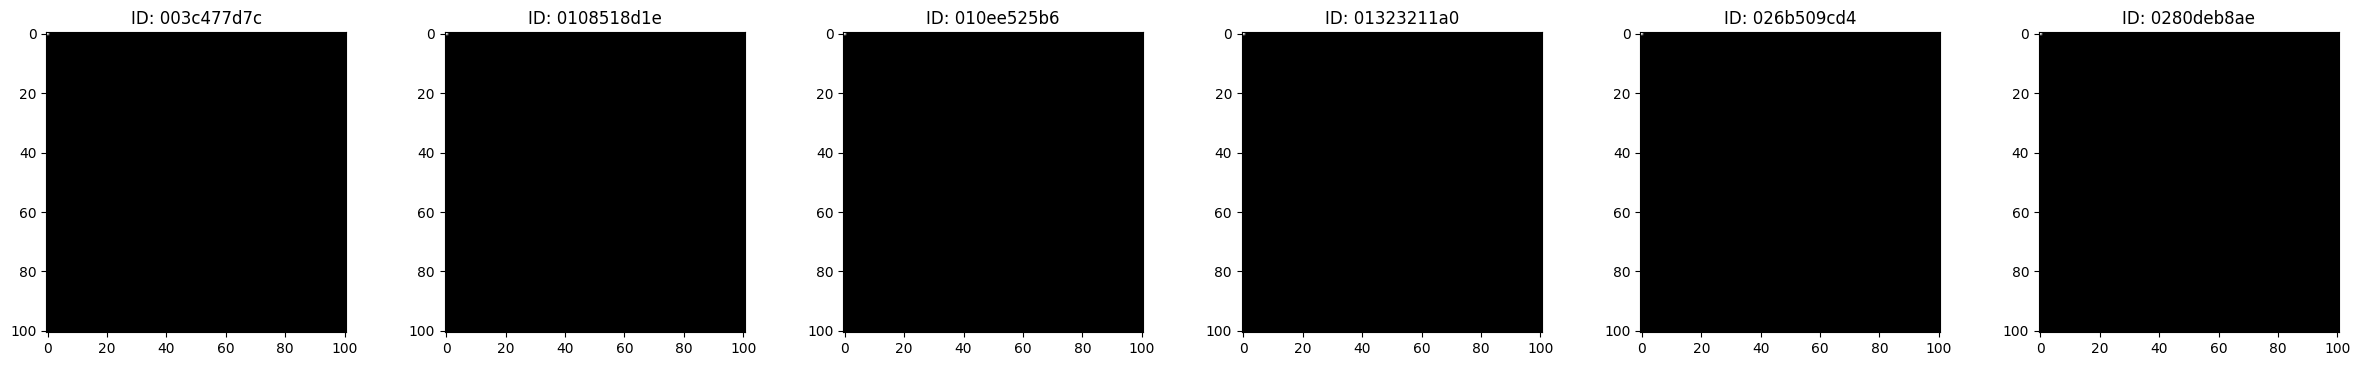

In [5]:
plt.figure(figsize=(30, 5))
plt.subplots_adjust(bottom=0.2, top=0.8, hspace=0.2)
for idx in range(min(6, len(df))):
    if pd.notna(df.loc[idx, "rle_mask"]):
        decoded_mask = rle_decode(df.loc[idx, "rle_mask"])
        plt.subplot(1, 6, idx + 1)
        plt.imshow(decoded_mask, cmap="gray")
        plt.title(f"ID: {df.loc[idx, 'id']}")
plt.show()




In [6]:
def crf(original_image, mask_img):
    """
    Apply DenseCRF refinement if the library is available.
    Otherwise return the original binary mask (no change).
    """
    if not HAVE_CRf:
        return mask_img.astype(np.uint8)

    if mask_img.ndim < 3:
        mask_img = gray2rgb(mask_img)

    annotated_label = (
        mask_img[:, :, 0] + (mask_img[:, :, 1] << 8) + (mask_img[:, :, 2] << 16)
    )

    colors, labels = np.unique(annotated_label, return_inverse=True)

    n_labels = 2  # background / salt

    d = dcrf.DenseCRF2D(original_image.shape[1], original_image.shape[0], n_labels)

    U = unary_from_labels(labels, n_labels, gt_prob=0.7, zero_unsure=False)
    d.setUnaryEnergy(U)

    d.addPairwiseGaussian(
        sxy=(3, 3),
        compat=3,
        kernel=dcrf.DIAG_KERNEL,
        normalization=dcrf.NORMALIZE_SYMMETRIC,
    )

    Q = d.inference(10)
    MAP = np.argmax(Q, axis=0)
    return MAP.reshape((original_image.shape[0], original_image.shape[1]))




In [7]:
test_path = os.path.join(base_path, "test", "images")
if not os.path.isdir(test_path):
    test_path = os.path.abspath(
        "../input/tgs-salt-identification-challenge/test/images"
    )



In [8]:
# Adjusted post‑processing to keep more true salt regions:
MIN_OBJECT_SIZE = 20  # lower threshold to retain small objects
KEEP_LARGEST_COMPONENT = False  # keep all plausible components


def keep_largest_component(mask):
    """
    Preserve only the largest connected component in a binary mask.
    """
    labeled = label(mask)
    if labeled.max() == 0:
        return mask
    largest_label = np.argmax(np.bincount(labeled.flat)[1:]) + 1
    return (labeled == largest_label).astype(np.uint8)


for i in tqdm(range(df.shape[0]), desc="Refining masks"):
    img_path = os.path.join(test_path, f"{df.loc[i, 'id']}.png")
    if not os.path.exists(img_path):
        continue

    orig_img = imread(img_path)

    if orig_img.ndim == 3 and orig_img.shape[2] == 4:
        img_rgb = orig_img[:, :, :3]
    elif orig_img.ndim == 3:
        img_rgb = orig_img
    else:
        img_rgb = np.stack([orig_img] * 3, axis=-1)

    gray = rgb2gray(img_rgb)
    gray_smooth = gaussian(gray, sigma=1)

    # Invert Otsu to treat bright pixels as salt (empirically better)
    thresh = threshold_otsu(gray_smooth)
    init_mask = (gray_smooth > thresh).astype(np.uint8)

    mask_closed = binary_closing(init_mask, footprint=np.ones((3, 3)))

    refined_mask = crf(orig_img, mask_closed)

    cleaned_mask = remove_small_objects(
        refined_mask.astype(bool), min_size=MIN_OBJECT_SIZE
    )
    cleaned_mask = binary_fill_holes(cleaned_mask)

    if KEEP_LARGEST_COMPONENT:
        cleaned_mask = keep_largest_component(cleaned_mask.astype(np.uint8))

    df.loc[i, "rle_mask"] = rle_encode(cleaned_mask.astype(np.uint8))



Refining masks: 100%|██████████| 1000/1000 [00:05<00:00, 197.84it/s]


In [9]:
output_path = "crf_correction_rlemasks.csv"
df.to_csv(output_path, index=False)
print(f"Submission saved to {output_path}")

Submission saved to crf_correction_rlemasks.csv
